In [33]:
!pip install kagglehub pandas matplotlib seaborn plotly
import kagglehub
import pandas as pd
import numpy as np
# Download latest version of the dataset programmatically
path = kagglehub.dataset_download("shivamb/netflix-shows")
print("Dataset downloaded to:", path)
# Load into pandas dataframe
df = pd.read_csv(f"{path}/netflix_titles.csv")

Using Colab cache for faster access to the 'netflix-shows' dataset.
Dataset downloaded to: /kaggle/input/netflix-shows


In [34]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [36]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [37]:
df[df['duration'].isnull()][['title', 'type', 'duration','rating', 'listed_in']]

,title,type,duration,rating,listed_in
5541,Louis C.K. 2017,Movie,NaN,74 min,Movies
5794,Louis C.K.: Hilarious,Movie,NaN,84 min,Movies
5813,Louis C.K.: Live at the Comedy Store,Movie,NaN,66 min,Movies


In [38]:
swapped_rows = df['duration'].isnull()
df.loc[swapped_rows, ['duration', 'rating']] = df.loc[swapped_rows, ['rating', 'duration']].values
# df.loc[swapped_rows, ['title', 'type', 'duration', 'rating']]
# df['duration'].isnull().sum()
df.loc[df.index.isin([5541, 5794, 5813]), ['title', 'duration', 'rating']]

,title,duration,rating
5541,Louis C.K. 2017,74 min,NaN
5794,Louis C.K.: Hilarious,84 min,NaN
5813,Louis C.K.: Live at the Comedy Store,66 min,NaN


In [39]:
import numpy as np
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

df['duration_minutes'] = np.where(df['type'] == 'Movie', df['duration_num'], np.nan)
df['duration_seasons'] = np.where(df['type'] == 'TV Show', df['duration_num'], np.nan)

df.drop(columns=['duration_num', 'duration'], inplace=True)

df[['type', 'duration_minutes', 'duration_seasons']].sample(10)

,type,duration_minutes,duration_seasons
5993,Movie,102.0,NaN
8077,Movie,93.0,NaN
2469,Movie,110.0,NaN
2949,Movie,106.0,NaN
1824,Movie,81.0,NaN
1487,TV Show,NaN,1.0
4072,Movie,102.0,NaN
7229,Movie,61.0,NaN
2518,TV Show,NaN,1.0
7725,TV Show,NaN,3.0


In [40]:
df_countries = df[['title', 'country']].dropna(subset=['country']).copy()
df_countries['country'] = df_countries['country'].str.split(', ')
df_countries = df_countries.explode('country')
df_countries['country'] = df_countries['country'].str.strip()

In [41]:
df_cast = df[['title', 'cast']].dropna(subset=['cast']).copy()
df_cast['cast'] = df_cast['cast'].str.split(', ')
df_cast = df_cast.explode('cast')
df_cast['cast'] = df_cast['cast'].str.strip()

In [42]:
df_director = df[['title', 'director']].dropna(subset=['director']).copy()
df_director['director'] = df_director['director'].str.split(', ')
df_director = df_director.explode('director')
df_director['director'] = df_director['director'].str.strip()

In [43]:
df_listed_in = df[['title', 'listed_in']].dropna(subset=['listed_in']).copy()
df_listed_in['listed_in'] = df_listed_in['listed_in'].str.split(', ')
df_listed_in = df_listed_in.explode('listed_in')
df_listed_in['listed_in'] = df_listed_in['listed_in'].str.strip()

In [53]:

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['day_added'] = df['date_added'].dt.day_name()


In [54]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

day_counts = df.dropna(subset=['day_added'])['day_added'].value_counts().reindex(day_order)
print(day_counts)

day_added
Monday        845
Tuesday      1182
Wednesday    1276
Thursday     1387
Friday       2476
Saturday      803
Sunday        740
Name: count, dtype: int64


In [45]:
df['date_added'].isnull().sum()

np.int64(98)

In [46]:
df[df['year_added'] == 2021]['date_added'].dt.month.value_counts().sort_index()

,count
date_added,
1,132
2,109
3,112
4,188
5,132
6,207
7,257
8,178
9,183


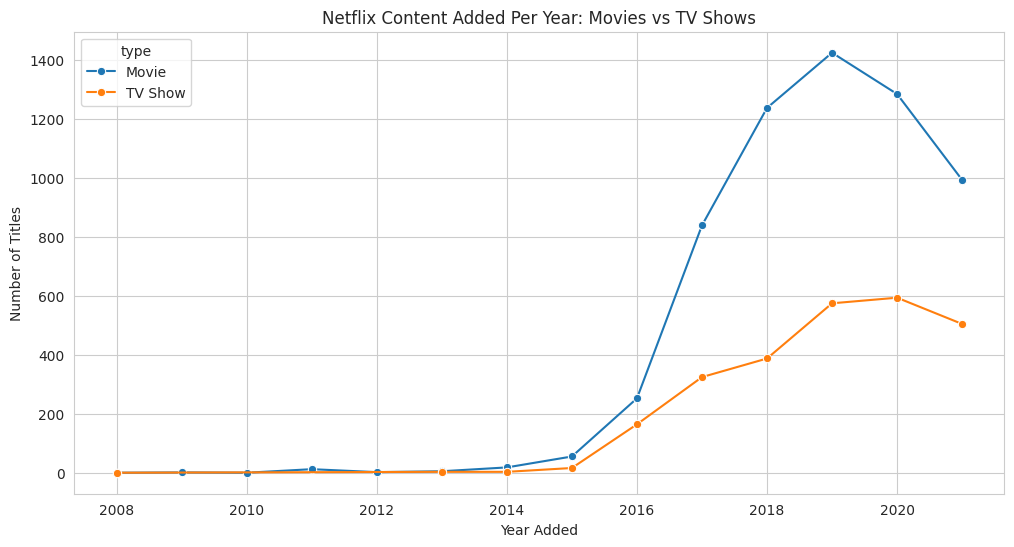

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

trend = df.dropna(subset=['year_added']).groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.lineplot(data=trend, x='year_added', y='count', hue='type', marker='o')
plt.title('Netflix Content Added Per Year: Movies vs TV Shows')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

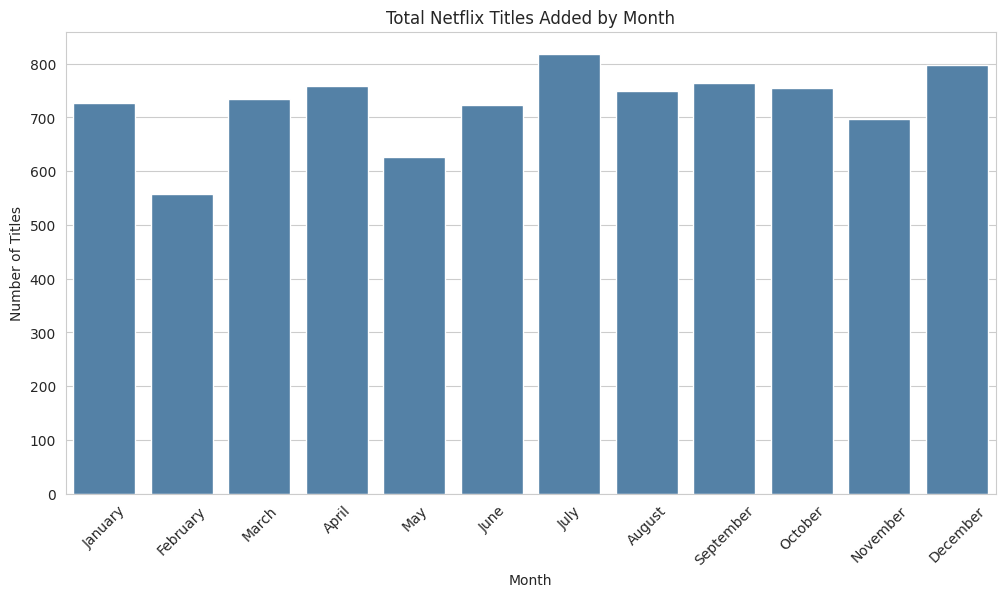

In [48]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df['month_name'] = df['date_added'].dt.month_name()

monthly_counts = df.dropna(subset=['month_name'])['month_name'].value_counts().reindex(month_order)

plt.figure(figsize=(12,6))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, color='steelblue')
plt.title('Total Netflix Titles Added by Month')
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

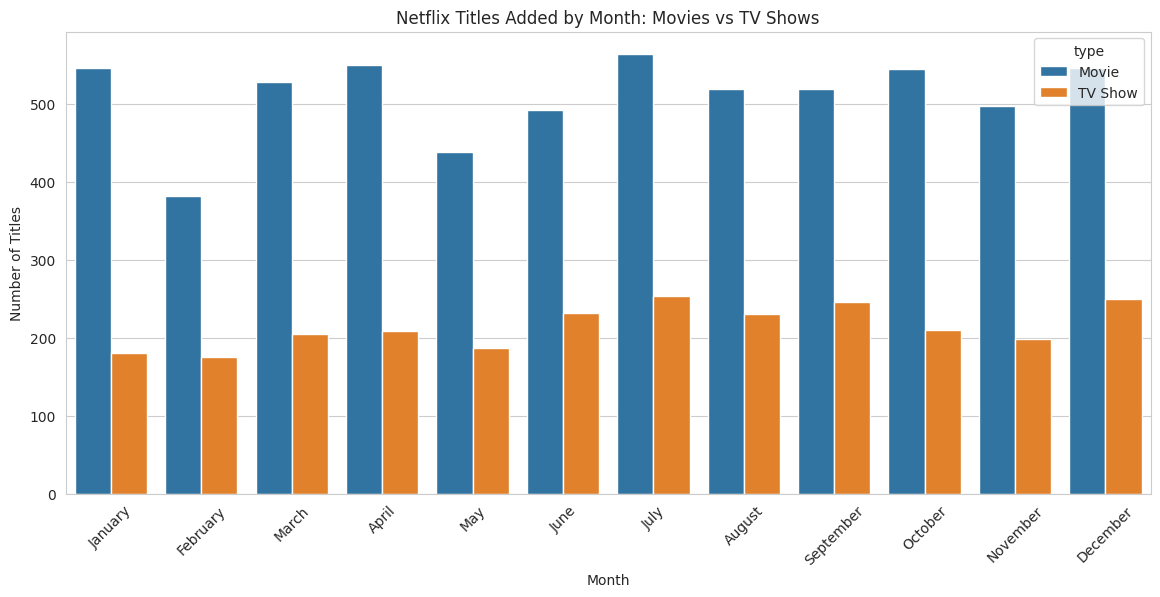

In [49]:
monthly_by_type = df.dropna(subset=['month_name']).groupby(['month_name','type']).size().reset_index(name='count')
monthly_by_type['month_name'] = pd.Categorical(monthly_by_type['month_name'], categories=month_order, ordered=True)
monthly_by_type = monthly_by_type.sort_values('month_name')

plt.figure(figsize=(14,6))
sns.barplot(data=monthly_by_type, x='month_name', y='count', hue='type')
plt.title('Netflix Titles Added by Month: Movies vs TV Shows')
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

In [50]:
monthly_counts.sort_values(ascending=False)

,count
month_name,
July,819
December,797
September,765
April,759
October,755
August,749
March,734
January,727
June,724


In [56]:
weekend_total = day_counts[['Saturday','Sunday']].sum()
weekday_total = day_counts[['Monday','Tuesday','Wednesday','Thursday','Friday']].sum()
print("Weekend avg per day:", weekend_total/2)
print("Weekday avg per day:", weekday_total/5)

Weekend avg per day: 771.5
Weekday avg per day: 1433.2


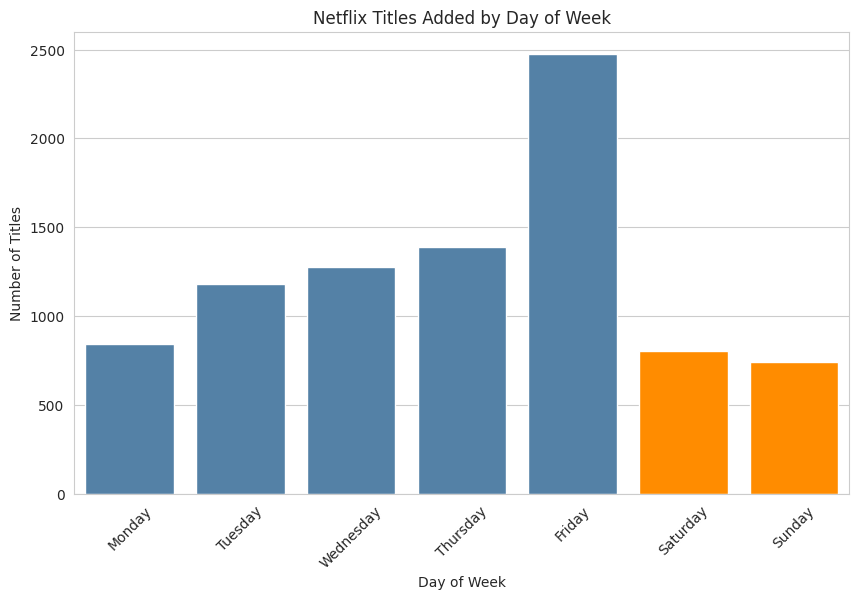

In [58]:
plt.figure(figsize=(10,6))
ax = sns.barplot(x=day_counts.index, y=day_counts.values, color='steelblue')

for i, day in enumerate(day_order):
    if day in ['Saturday', 'Sunday']:
        ax.patches[i].set_facecolor('darkorange')

plt.title('Netflix Titles Added by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

In [60]:
from itertools import combinations

# only titles with 2+ countries can have a collaboration
multi_country = df[['title','country']].dropna(subset=['country']).copy()
multi_country['country_list'] = multi_country['country'].str.split(', ').apply(lambda x: [c.strip() for c in x])
multi_country = multi_country[multi_country['country_list'].apply(len) > 1]

pairs = []
for countries in multi_country['country_list']:
    for pair in combinations(sorted(set(countries)), 2):
        pairs.append(pair)

pair_counts = pd.Series(pairs).value_counts().head(15)
print(pair_counts)

(United Kingdom, United States)    279
(Canada, United States)            217
(France, United States)            125
(Germany, United States)            88
(France, United Kingdom)            67
(Japan, United States)              63
(Canada, United Kingdom)            58
(Belgium, France)                   57
(Germany, United Kingdom)           52
(China, United States)              50
(Australia, United States)          48
(Mexico, United States)             42
(France, Germany)                   41
(China, Hong Kong)                  38
(India, United States)              38
Name: count, dtype: int64


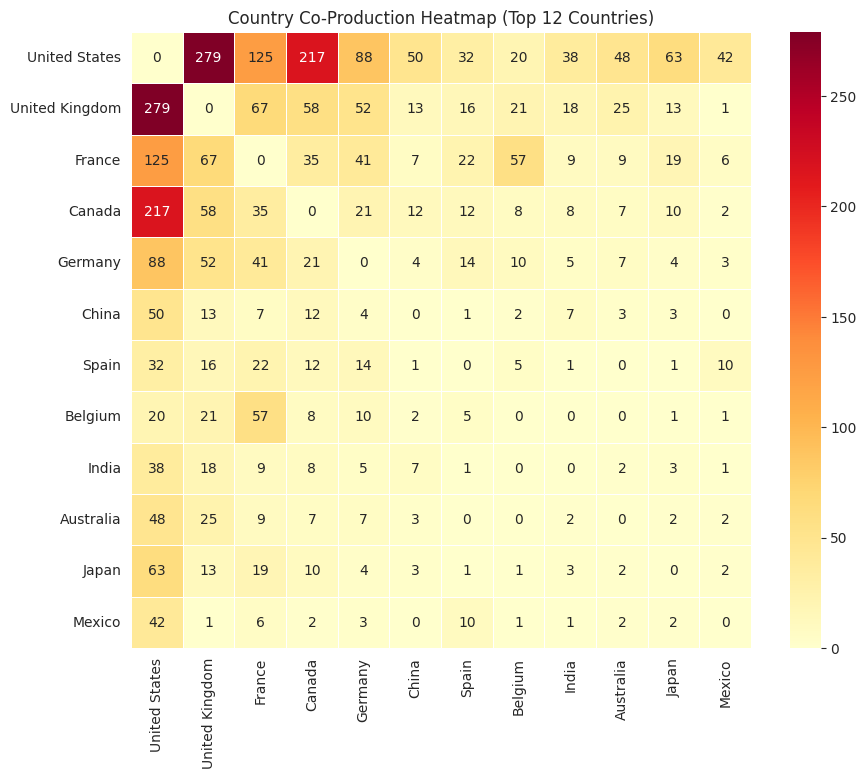

In [65]:
top_countries = (
    multi_country['country_list']
    .explode()
    .value_counts()
    .head(12)
    .index.tolist()
)

matrix = pd.DataFrame(0, index=top_countries, columns=top_countries)

for countries in multi_country['country_list']:
    relevant = [c for c in set(countries) if c in top_countries]
    for a, b in combinations(sorted(relevant), 2):
        matrix.loc[a, b] += 1
        matrix.loc[b, a] += 1  # mirror, since collaboration is symmetric

plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Country Co-Production Heatmap (Top 12 Countries)')
plt.show()


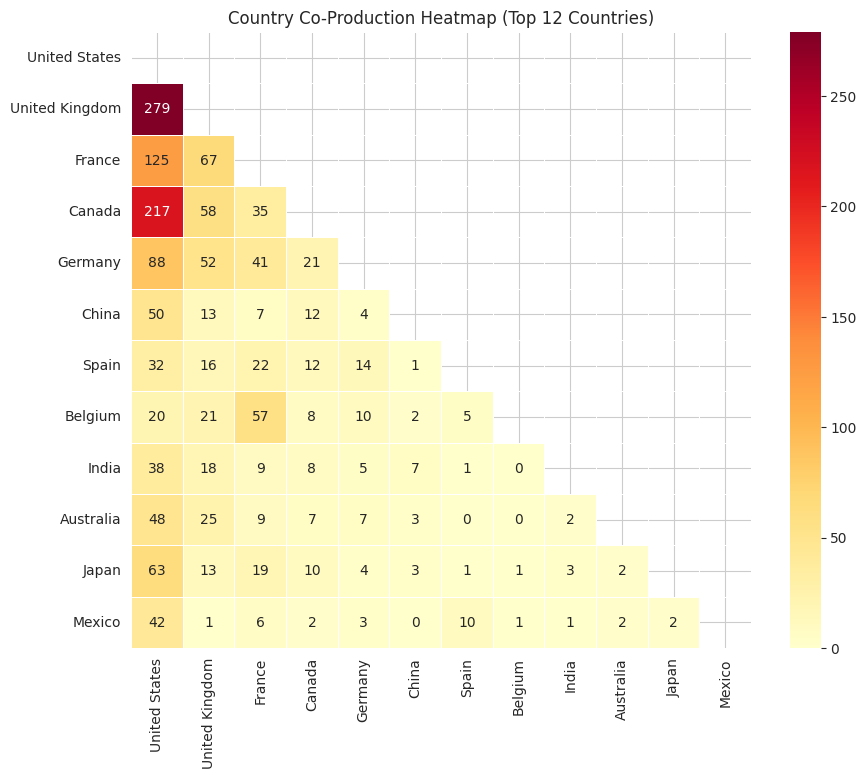

In [67]:
import numpy as np

mask = np.triu(np.ones_like(matrix, dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, mask=mask)
plt.title('Country Co-Production Heatmap (Top 12 Countries)')
plt.show()

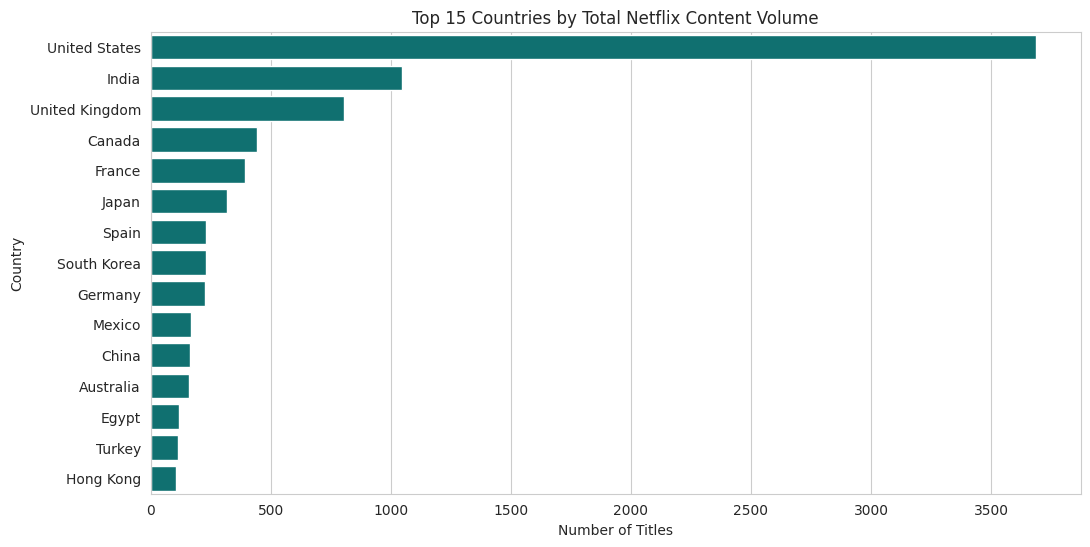

In [68]:
country_totals = (
    df[['title','country']]
    .dropna(subset=['country'])
    .assign(country=lambda d: d['country'].str.split(', '))
    .explode('country')
)
country_totals['country'] = country_totals['country'].str.strip()

top15 = country_totals['country'].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=top15.values, y=top15.index, color='teal')
plt.title('Top 15 Countries by Total Netflix Content Volume')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

In [69]:
ad = df[['title','cast','director']].dropna(subset=['cast','director']).copy()
ad['cast_list'] = ad['cast'].str.split(', ').apply(lambda x: [c.strip() for c in x])
ad['director_list'] = ad['director'].str.split(', ').apply(lambda x: [d.strip() for d in x])

duos = []
for _, row in ad.iterrows():
    for actor in row['cast_list']:
        for director in row['director_list']:
            duos.append((actor, director))

duo_counts = pd.Series(duos).value_counts().head(15)
print(duo_counts)

(Julie Tejwani, Rajiv Chilaka)           19
(Rajesh Kava, Rajiv Chilaka)             19
(Rupa Bhimani, Rajiv Chilaka)            18
(Jigna Bhardwaj, Rajiv Chilaka)          18
(Vatsal Dubey, Rajiv Chilaka)            16
(Swapnil, Rajiv Chilaka)                 13
(Mousam, Rajiv Chilaka)                  13
(Saurav Chakraborty, Suhas Kadav)         8
(Prabhas, S.S. Rajamouli)                 7
(Anushka Shetty, S.S. Rajamouli)          7
(Kappei Yamaguchi, Toshiya Shinohara)     7
(Rana Daggubati, S.S. Rajamouli)          7
(Koji Tsujitani, Toshiya Shinohara)       7
(Houko Kuwashima, Toshiya Shinohara)      7
(Ramya Krishnan, S.S. Rajamouli)          7
Name: count, dtype: int64


In [70]:
df[df['director'] == 'Rajiv Chilaka'][['title','type']].drop_duplicates()


,title,type
406,Chhota Bheem - Neeli Pahaadi,Movie
407,Chhota Bheem & Ganesh,Movie
408,Chhota Bheem & Krishna: Mayanagari,Movie
409,Chhota Bheem & Krishna: Pataliputra- City of t...,Movie
410,Chhota Bheem And The Broken Amulet,Movie
411,Chhota Bheem And The Crown of Valhalla,Movie
412,Chhota Bheem and the Incan Adventure,Movie
413,Chhota Bheem and The ShiNobi Secret,Movie
414,Chhota Bheem Aur Hanuman,Movie
415,Chhota Bheem aur Krishna,Movie


In [71]:
top_actors = df_cast['cast'].value_counts().head(10)
print(top_actors)

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Rupa Bhimani        31
Om Puri             30
Akshay Kumar        30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64


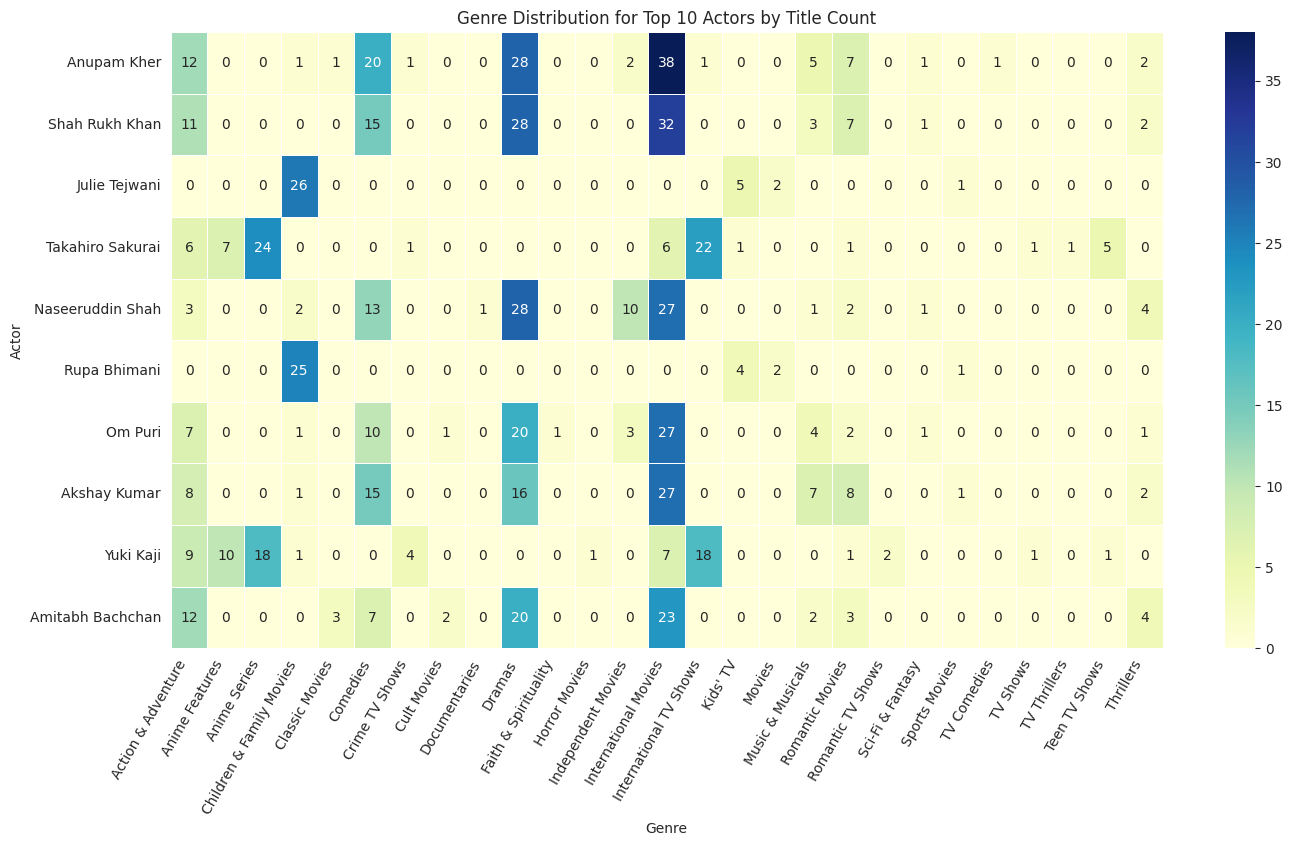

In [74]:
top_actor_names = top_actors.index.tolist()

actor_genre = df_cast[df_cast['cast'].isin(top_actor_names)][['title','cast']].merge(
    df[['title','listed_in']], on='title', how='left'
)

actor_genre = actor_genre.dropna(subset=['listed_in']).copy()
actor_genre['listed_in'] = actor_genre['listed_in'].str.split(', ').apply(lambda x: [g.strip() for g in x])
actor_genre = actor_genre.explode('listed_in')

genre_matrix = actor_genre.groupby(['cast','listed_in']).size().unstack(fill_value=0)
genre_matrix = genre_matrix.loc[top_actor_names]  # keep original ranking order

plt.figure(figsize=(16,8))
sns.heatmap(genre_matrix, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5)
plt.title('Genre Distribution for Top 10 Actors by Title Count')
plt.xlabel('Genre')
plt.ylabel('Actor')
plt.xticks(rotation=60, ha='right')
plt.show()

In [75]:
from itertools import combinations

genre_combo = df[['title','listed_in']].dropna(subset=['listed_in']).copy()
genre_combo['genre_list'] = genre_combo['listed_in'].str.split(', ').apply(lambda x: [g.strip() for g in x])

combo_pairs = []
for genres in genre_combo['genre_list']:
    for pair in combinations(sorted(set(genres)), 2):
        combo_pairs.append(pair)

combo_counts = pd.Series(combo_pairs).value_counts().head(15)
print(combo_counts)

(Dramas, International Movies)                 1483
(Comedies, International Movies)                804
(Dramas, Independent Movies)                    588
(International TV Shows, TV Dramas)             514
(Comedies, Dramas)                              502
(Action & Adventure, International Movies)      398
(International Movies, Romantic Movies)         372
(International TV Shows, Romantic TV Shows)     315
(Dramas, Romantic Movies)                       308
(Crime TV Shows, International TV Shows)        299
(Documentaries, International Movies)           296
(Independent Movies, International Movies)      292
(Comedies, Romantic Movies)                     277
(International Movies, Thrillers)               272
(Children & Family Movies, Comedies)            270
Name: count, dtype: int64


In [76]:
df[df['listed_in'].str.contains('International Movies', na=False)]['country'].dropna().str.contains('United States').value_counts()

,count
country,
False,2377
True,166


In [77]:
import re
from collections import Counter

horror = df[df['listed_in'].str.contains('Horror', na=False)]['description']
comedy = df[df['listed_in'].str.contains('Comedies', na=False)]['description']

print("Horror titles:", len(horror))
print("Comedy titles:", len(comedy))

stopwords = set([
    'the','a','an','and','or','of','to','in','is','it','this','that','with',
    'for','on','as','by','at','his','her','their','from','but','are',
    'be','has','have','was','were','he','she','they','its','who','when',
    'after','into','out','about','more','can','will','one','two','new',
    'life','up','not','all','him','what','than','then','where','while',
    'must','only','their','them','her'
])

def get_word_counts(text_series, top_n=20):
    text = ' '.join(text_series.dropna()).lower()
    words = re.findall(r'\b[a-z]+\b', text)
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(top_n)

horror_words = get_word_counts(horror)
comedy_words = get_word_counts(comedy)

print("Top Horror words:", horror_words)
print("Top Comedy words:", comedy_words)

Horror titles: 432
Comedy titles: 2255
Top Horror words: [('young', 51), ('home', 47), ('woman', 36), ('family', 35), ('group', 34), ('mysterious', 34), ('horror', 32), ('find', 32), ('house', 28), ('friends', 28), ('supernatural', 28), ('finds', 25), ('evil', 24), ('town', 23), ('mother', 23), ('past', 23), ('spirit', 22), ('begins', 21), ('series', 21), ('couple', 20)]
Top Comedy words: [('family', 185), ('man', 178), ('friends', 170), ('young', 160), ('love', 151), ('woman', 145), ('school', 133), ('find', 117), ('high', 110), ('three', 110), ('comedy', 106), ('world', 105), ('help', 103), ('old', 96), ('father', 93), ('series', 93), ('home', 92), ('get', 91), ('finds', 89), ('back', 89)]


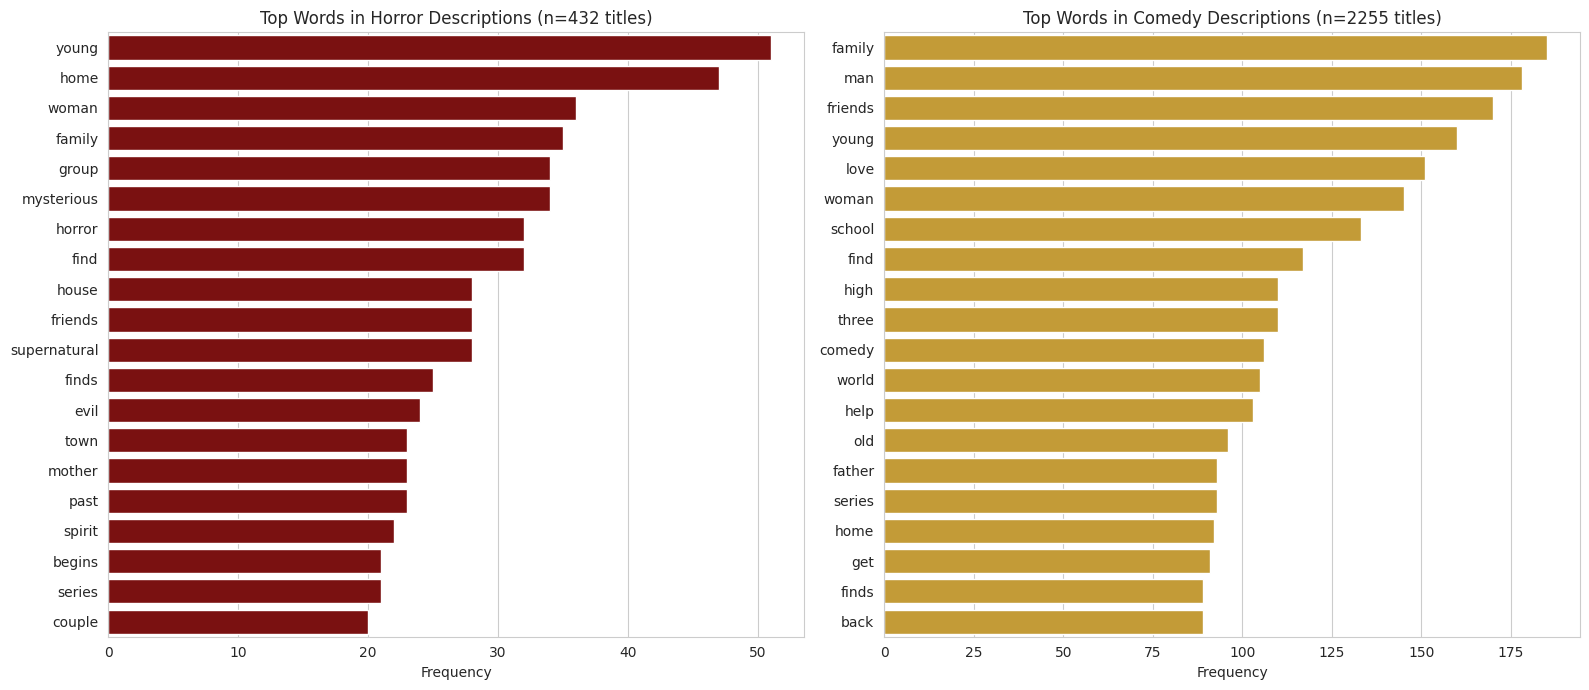

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16,7))

h_words, h_counts = zip(*horror_words)
sns.barplot(x=list(h_counts), y=list(h_words), color='darkred', ax=axes[0])
axes[0].set_title(f'Top Words in Horror Descriptions (n={len(horror)} titles)')
axes[0].set_xlabel('Frequency')

c_words, c_counts = zip(*comedy_words)
sns.barplot(x=list(c_counts), y=list(c_words), color='goldenrod', ax=axes[1])
axes[1].set_title(f'Top Words in Comedy Descriptions (n={len(comedy)} titles)')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()